In [2]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

NetKet version: 3.21.1.dev13+gbf43effcb


In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
from flax.core import freeze, unfreeze

print("=" * 80)
print(">>> [VMC 终极流水线] 阶段一(RHF) -> 阶段二(AGP+Jastrow) -> 阶段三(AGP+NeuralJastrow)")
print("=" * 80)

# ======================================================================
# 【模型定义部分】
# ======================================================================

# 阶段一：Slater 决定式 (已提供)
class SlaterExpm(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        kappa_vec = self.param('kappa_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        kappa_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        kappa = kappa_zeros.at[tril_rows, tril_cols].set(kappa_vec)
        kappa = kappa.at[tril_cols, tril_rows].set(-kappa_vec) 
        
        U = jax.scipy.linalg.expm(kappa)
        Phi_occ = U[:, :self.n_up]
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_slater(idx):
            return Phi_occ[idx, :]
            
        sub_Phi_up = jax.vmap(extract_slater)(idx_up) if x.ndim > 1 else extract_slater(idx_up)
        sub_Phi_down = jax.vmap(extract_slater)(idx_down) if x.ndim > 1 else extract_slater(idx_down)
        
        sign_u, log_det_u = jnp.linalg.slogdet(sub_Phi_up)
        sign_d, log_det_d = jnp.linalg.slogdet(sub_Phi_down)
        return log_det_u + log_det_d + jnp.log((sign_u * sign_d).astype(jnp.complex128))

# 阶段二：纯 Singlet AGP + 局域单参数 Jastrow (已提供)
class AGPSIAMJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        kappa_vec = self.param('kappa_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        
        def init_fermi_sea(key, shape, dtype):
            base = jnp.zeros(shape, dtype=dtype)
            return base.at[:self.n_up].set(1.0)
            
        lambdas = self.param('pairing_eigenvalues', init_fermi_sea, (self.n_sites,), dtype)
        
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        kappa_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        kappa = kappa_zeros.at[tril_rows, tril_cols].set(kappa_vec)
        kappa = kappa.at[tril_cols, tril_rows].set(-kappa_vec) 
        
        U = jax.scipy.linalg.expm(kappa)
        F_matrix = jnp.dot(U * lambdas, U.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        is_double_occupied = n[..., 0] * n[..., self.n_sites]
        log_jastrow = -g * is_double_occupied.astype(dtype)
        
        return log_agp + log_jastrow

# 阶段三：纯 Singlet AGP + 全局 Neural Jastrow (最原始基底版)
class AGPSIAMNeuralJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int
    hidden_dims: tuple = (4, 4) # 神经网络隐藏层大小

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # --- 1. AGP 部分 (与阶段二完全相同，确保可继承) ---
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        kappa_vec = self.param('kappa_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        
        def init_fermi_sea(key, shape, dtype):
            base = jnp.zeros(shape, dtype=dtype)
            return base.at[:self.n_up].set(1.0)
        lambdas = self.param('pairing_eigenvalues', init_fermi_sea, (self.n_sites,), dtype)
        
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        kappa_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        kappa = kappa_zeros.at[tril_rows, tril_cols].set(kappa_vec)
        kappa = kappa.at[tril_cols, tril_rows].set(-kappa_vec) 
        
        U = jax.scipy.linalg.expm(kappa)
        F_matrix = jnp.dot(U * lambdas, U.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # --- 2. Neural Jastrow 部分 (原始基底) ---
        # 直接把全空间构型 x (即 [n_1↑, ..., n_L↑, n_1↓, ..., n_L↓]) 喂给神经网络
        # 此时网络输入维度为 2 * n_sites
        y = x
        for dim in self.hidden_dims:
            y = nn.Dense(features=dim, dtype=dtype)(y)
            y = nn.gelu(y) # 非线性激活
            
        log_neural_jastrow = nn.Dense(features=1, dtype=dtype)(y)
        log_neural_jastrow = jnp.squeeze(log_neural_jastrow, axis=-1)
        
        return log_agp + log_neural_jastrow

>>> [VMC 终极流水线] 阶段一(RHF) -> 阶段二(AGP+Jastrow) -> 阶段三(AGP+NeuralJastrow)


chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


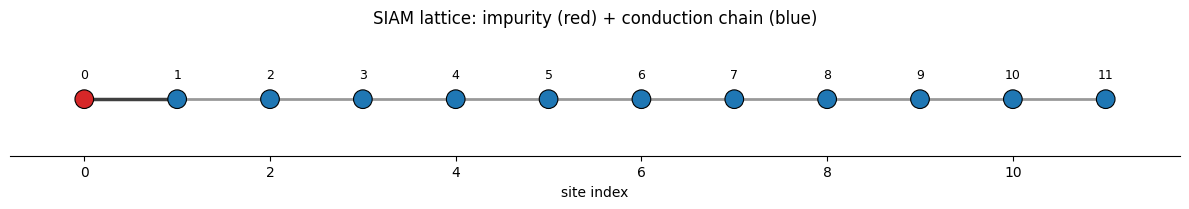

In [6]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))


U = 4.0
V = 0.15
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

h_pin = 0.00
H -= h_pin * 0.5 * (n_d_up - n_d_dn)
# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


In [8]:
# ======================================================================
# 【优化器配置生成器】
# ======================================================================
def get_optimizer_and_sr(steps=300):
    lr_schedule = optax.cosine_decay_schedule(init_value=0.002, decay_steps=steps, alpha=0.01)
    op = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=lr_schedule, b1=0.8, b2=0.999, eps=1e-8))
    sr_shift = optax.linear_schedule(init_value=0.05, end_value=0.001, transition_steps=int(steps*0.6))
    sr = nk.optimizer.SR(diag_shift=sr_shift, solver=nk.optimizer.solver.pinv, holomorphic=False, qgt=nk.optimizer.qgt.QGTJacobianDense)
    return op, sr

# 通用参数定义 (假设外部环境已定义 hi, H, graph_sampler, n_orbitals, N_up, N_dn)
N_ITER = 300
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# ======================================================================
# >>> 阶段一：Slater 决定式 (基底预热)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 Slater 决定式 (寻找最优轨道基底)...")
model_1 = SlaterExpm(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**12, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)

gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
gs_1.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 1 完成] RHF 能量: {vs_1.expect(H).mean.real:.6f}")

# ======================================================================
# >>> 阶段二：AGP + 标量 Jastrow (近藤物理激活)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 2/3] 正在训练 AGP + Jastrow (参数热启动中)...")
model_2 = AGPSIAMJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_2 = nk.vqs.MCState(sampler=sa, model=model_2, n_samples=2**12, n_discard_per_chain=32)

# 参数继承 1 -> 2
params_2 = unfreeze(vs_2.parameters)
params_2['kappa_vec'] = vs_1.parameters['kappa_vec']  # 继承轨道基底
vs_2.parameters = freeze(params_2)
print(" [+] 成功从 Stage 1 继承: kappa_vec")

op_2, sr_2 = get_optimizer_and_sr(N_ITER)
gs_2 = nk.VMC(hamiltonian=H, optimizer=op_2, preconditioner=sr_2, variational_state=vs_2)
gs_2.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 2 完成] AGP+Jastrow 能量: {vs_2.expect(H).mean.real:.6f}")

# ======================================================================
# >>> 阶段三：AGP + Neural Jastrow (捕捉非局域强关联)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 3/3] 正在训练 AGP + Neural Jastrow (参数终极热启动中)...")
model_3 = AGPSIAMNeuralJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn, hidden_dims=(8,))
vs_3 = nk.vqs.MCState(sampler=sa, model=model_3, n_samples=2**12, n_discard_per_chain=32)

# 参数继承 2 -> 3
params_3 = unfreeze(vs_3.parameters)
params_3['kappa_vec'] = vs_2.parameters['kappa_vec']                 # 继承轨道基底
params_3['pairing_eigenvalues'] = vs_2.parameters['pairing_eigenvalues'] # 继承配对关联
# 注意：Dense 层的权重是新建的，从随机数开始训练
vs_3.parameters = freeze(params_3)
print(" [+] 成功从 Stage 2 继承: kappa_vec")
print(" [+] 成功从 Stage 2 继承: pairing_eigenvalues")

op_3, sr_3 = get_optimizer_and_sr(N_ITER)
gs_3 = nk.VMC(hamiltonian=H, optimizer=op_3, preconditioner=sr_3, variational_state=vs_3)
gs_3.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 3 完成] AGP+NeuralJastrow 能量: {vs_3.expect(H).mean.real:.6f}")
print("=" * 80)
print("🎉 恭喜！流水线执行完毕。现在你可以用 vs_3 去对比 ED 的精确结果了！")


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 Slater 决定式 (寻找最优轨道基底)...


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [06:07<00:00,  1.23s/it, Energy=-9.233+0.000j ± 0.054 [σ²=3.2e+00, R̂=1.034]]


[Stage 1 完成] RHF 能量: -9.263879

--------------------------------------------------------------------------------
>>> [Stage 2/3] 正在训练 AGP + Jastrow (参数热启动中)...


ParameterMismatchError: 
The structure of the parameters does not match the expected structure.

Expected structure: PyTreeDef({'impurity_penalty': *, 'kappa_vec': *, 'pairing_eigenvalues': *})
Structure of the parameters: PyTreeDef(CustomNode(FrozenDict[('impurity_penalty', 'kappa_vec', 'pairing_eigenvalues')], [*, *, *]))

This error is because you attempted to modify the ``parameters`` or ``variables`` attribute of a
variational state with a structure that does not match the previous structure.

To fix this error, you should ensure that the structure of the parameters you are trying to assign
matches the structure of the parameters that were already present in the variational state.

If you believe this error was thrown in error, or it prevents you from doing something, please open an issue.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.

In [9]:
# ======================================================================
# 【优化器配置生成器】
# ======================================================================
def get_optimizer_and_sr(steps=300):
    lr_schedule = optax.cosine_decay_schedule(init_value=0.002, decay_steps=steps, alpha=0.01)
    op = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=lr_schedule, b1=0.8, b2=0.999, eps=1e-8))
    sr_shift = optax.linear_schedule(init_value=0.05, end_value=0.001, transition_steps=int(steps*0.6))
    sr = nk.optimizer.SR(diag_shift=sr_shift, solver=nk.optimizer.solver.pinv, holomorphic=False, qgt=nk.optimizer.qgt.QGTJacobianDense)
    return op, sr

# 通用参数定义 (假设外部环境已定义 hi, H, graph_sampler, n_orbitals, N_up, N_dn)
N_ITER = 300
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# ======================================================================
# >>> 阶段一：Slater 决定式 (基底预热)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 Slater 决定式 (寻找最优轨道基底)...")
model_1 = SlaterExpm(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**13, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)

gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
gs_1.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 1 完成] RHF 能量: {vs_1.expect(H).mean.real:.6f}")

# ======================================================================
# >>> 阶段二：AGP + 标量 Jastrow (近藤物理激活)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 2/3] 正在训练 AGP + Jastrow (参数热启动中)...")
model_2 = AGPSIAMJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_2 = nk.vqs.MCState(sampler=sa, model=model_2, n_samples=2**13, n_discard_per_chain=32)

# 参数继承 1 -> 2
params_2 = unfreeze(vs_2.parameters)
params_2['kappa_vec'] = vs_1.parameters['kappa_vec']  # 继承轨道基底
vs_2.parameters = freeze(params_2)
print(" [+] 成功从 Stage 1 继承: kappa_vec")

op_2, sr_2 = get_optimizer_and_sr(N_ITER)
gs_2 = nk.VMC(hamiltonian=H, optimizer=op_2, preconditioner=sr_2, variational_state=vs_2)
gs_2.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 2 完成] AGP+Jastrow 能量: {vs_2.expect(H).mean.real:.6f}")

# ======================================================================
# >>> 阶段三：AGP + Neural Jastrow (捕捉非局域强关联)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 3/3] 正在训练 AGP + Neural Jastrow (参数终极热启动中)...")
model_3 = AGPSIAMNeuralJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn, hidden_dims=(8,))
vs_3 = nk.vqs.MCState(sampler=sa, model=model_3, n_samples=2**13, n_discard_per_chain=32)

# 参数继承 2 -> 3
params_3 = unfreeze(vs_3.parameters)
params_3['kappa_vec'] = vs_2.parameters['kappa_vec']                 # 继承轨道基底
params_3['pairing_eigenvalues'] = vs_2.parameters['pairing_eigenvalues'] # 继承配对关联
# 注意：Dense 层的权重是新建的，从随机数开始训练
vs_3.parameters = freeze(params_3)
print(" [+] 成功从 Stage 2 继承: kappa_vec")
print(" [+] 成功从 Stage 2 继承: pairing_eigenvalues")

op_3, sr_3 = get_optimizer_and_sr(N_ITER)
gs_3 = nk.VMC(hamiltonian=H, optimizer=op_3, preconditioner=sr_3, variational_state=vs_3)
gs_3.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 3 完成] AGP+NeuralJastrow 能量: {vs_3.expect(H).mean.real:.6f}")
print("=" * 80)
print("🎉 恭喜！流水线执行完毕。现在你可以用 vs_3 去对比 ED 的精确结果了！")


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 Slater 决定式 (寻找最优轨道基底)...


100%|██████████| 300/300 [05:08<00:00,  1.03s/it, Energy=-10.813+0.000j ± 0.023 [σ²=1.8e+00, R̂=1.003]]                                           


[Stage 1 完成] RHF 能量: -10.812382

--------------------------------------------------------------------------------
>>> [Stage 2/3] 正在训练 AGP + Jastrow (参数热启动中)...


ParameterMismatchError: 
The structure of the parameters does not match the expected structure.

Expected structure: PyTreeDef({'impurity_penalty': *, 'kappa_vec': *, 'pairing_eigenvalues': *})
Structure of the parameters: PyTreeDef(CustomNode(FrozenDict[('impurity_penalty', 'kappa_vec', 'pairing_eigenvalues')], [*, *, *]))

This error is because you attempted to modify the ``parameters`` or ``variables`` attribute of a
variational state with a structure that does not match the previous structure.

To fix this error, you should ensure that the structure of the parameters you are trying to assign
matches the structure of the parameters that were already present in the variational state.

If you believe this error was thrown in error, or it prevents you from doing something, please open an issue.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.

In [10]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

In [11]:
model_1 = LogSlaterDeterminant(hilbert=hi)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**12, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)

gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
gs_1.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 1 完成] RHF 能量: {vs_1.expect(H).mean.real:.6f}")

100%|██████████| 300/300 [02:42<00:00,  1.85it/s, Energy=-12.088+0.000j ± 0.049 [σ²=2.3e+00, R̂=1.070]]


[Stage 1 完成] RHF 能量: -12.045788
